## Deep Agent Overview 

Build agents that can plan, use subagents and leverage file systems for complex tasks

Deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Build on LangGraph and inspired by applications like Claude Code, Deep Research and Manus, deep agents come with planning capabilities, file systems for context management and the ability to spawn subagents. 

### When to use Deep Agents 
Use Deep agents when you need agents that can: 
- Handle complex, multi-step tasks that require planning and decomposition 
- Manage large amounts of context through file system tools 
- Delegate work to specialized subagents for context isolation 
- Persists memory across conversations and threads

In [3]:
### Basic Deep Agent 

import os 
from dotenv import load_dotenv

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')



In [11]:
# Tools Internet search 
from tavily import TavilyClient
from typing import Literal

tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str,max_results:int=5,
topic: Literal["general","sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic=topic)


In [19]:
from langchain.chat_models import init_chat_model 

model = init_chat_model("groq:qwen/qwen3.6-27b")

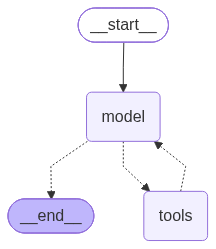

In [20]:
## Basic Agent
from langchain.agents import create_agent


simple_agent=create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

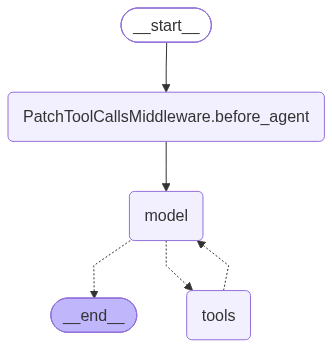

In [21]:
## Create a Deep agent 

## Prompt 


## Agent 

### Create a deep agent
## Prompt

## agent

from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

In [23]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result 

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='cfadf06d-a6b7-478a-8161-3aa175bdeb0d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking "What is deepagent?".\nI need to find information about "deepagent".\nI will use the `web_search` tool to find relevant information.\nThen I will summarize the findings.\n', 'tool_calls': [{'id': 'f76keydd6', 'function': {'arguments': '{"query":"What is deepagent?"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 2855, 'total_tokens': 2932, 'completion_time': 0.146537764, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.198045495, 'prompt_tokens_details': None, 'queue_time': 0.052854985, 'total_time': 0.344583259}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_49d6b1859d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None,

In [24]:
result["messages"][-1].content

'Depending on the context, **DeepAgent** (or **Deep Agents**) refers to one of three distinct but related things in the current AI landscape.\n\n### 1. The AI Concept (NVIDIA’s Definition)\nIn the broader AI industry, a **Deep Agent** is a classification of advanced AI architecture designed to handle complex, long-running, and multi-step workflows. \n* **Deep vs. Shallow:** Unlike "shallow" agents that perform simple, single-step tasks (like answering a quick question or running a single search), deep agents act like autonomous project managers. \n* **Key Capabilities:** They utilize explicit planning, persistent long-term memory, tool execution, and **sub-agent delegation** (the ability to spawn smaller, specialized agents to handle parts of a larger goal).\n\n### 2. The Open-Source Framework (LangChain `deepagents`)\n**DeepAgents** is a popular open-source library created by **LangChain** that allows developers to easily build the type of deep agents described above. \n* It is a "bat

What happened ? 

Your deep agent automatically: 
- Planned its approach: Used the built-in write_todos to break down the research task 
- Conducted research: Called the internet_search tool to gather information 
- Managed Context: Used file system toosl (write_file, read_file) to offload large search results 
- Spawned subagens (if needed): delegated complex subtasks to specialized subagents 
- Synthesized a report: Compiled findings into a coherent resposne 

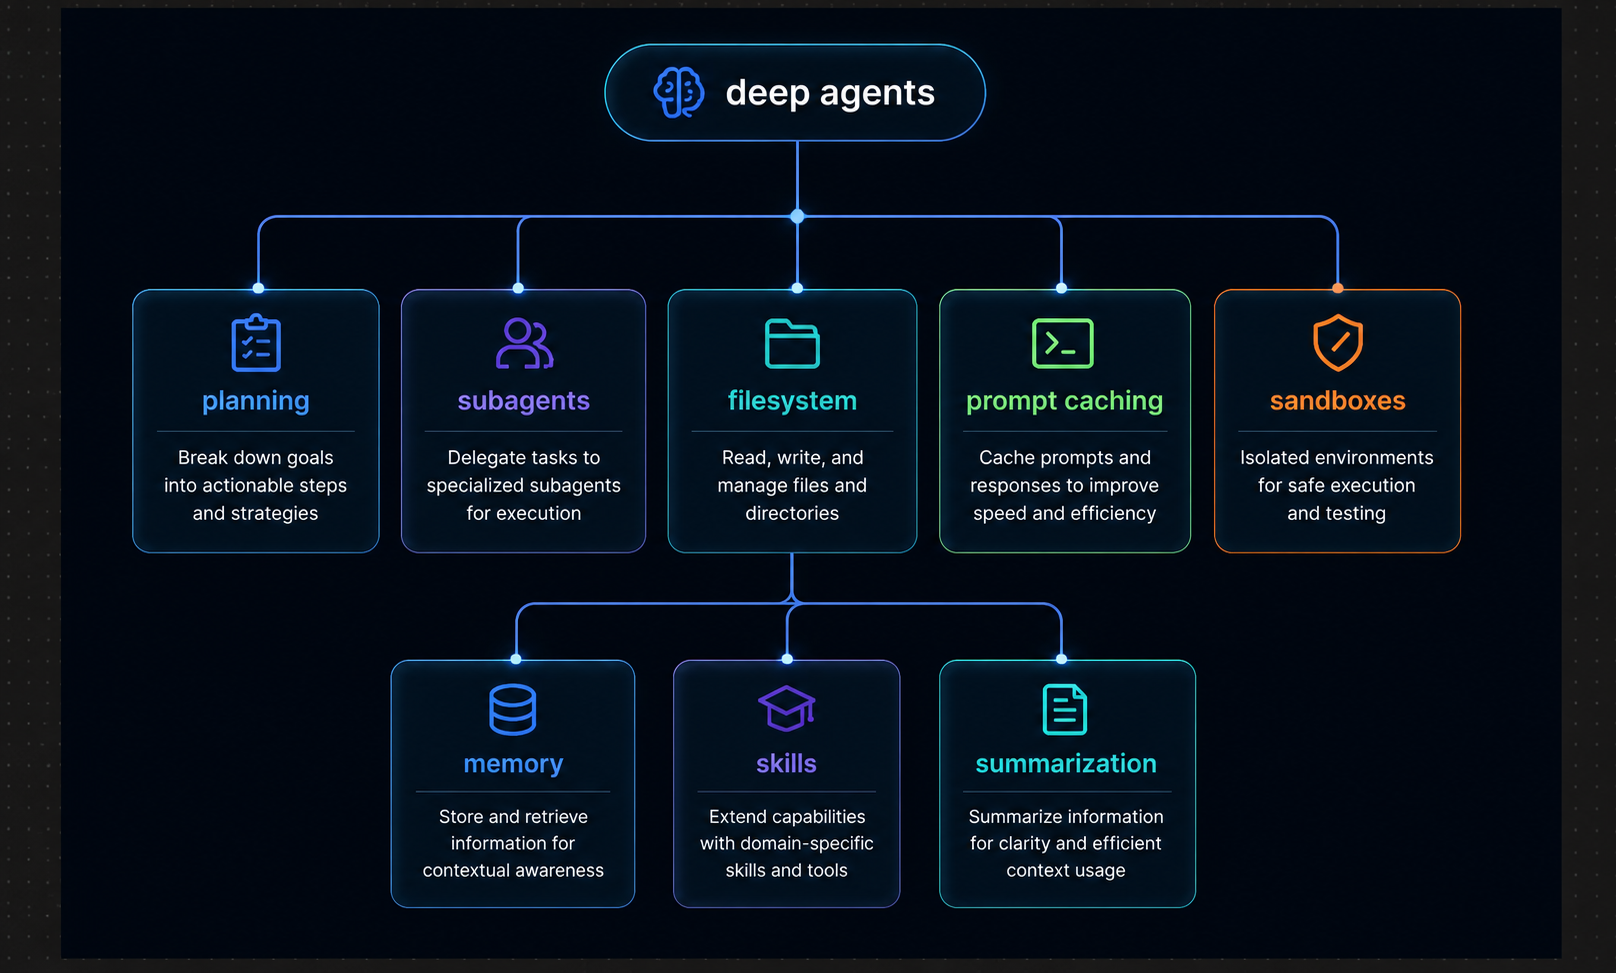